In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from tqdm import tqdm
import seaborn as sns

In [2]:
npz_files = sorted(glob.glob("*.npz"), key=lambda x: int(x.split(".")[0]))
iterations = [int(file.split(".")[0]) for file in npz_files]

In [3]:
distilled_data = {}

for file in tqdm(npz_files):
    iteration = int(file.split(".")[0])
    data = np.load(file)
    distilled_data[iteration] = {key: data[key] for key in data.keys()}

  0%|          | 0/24 [00:00<?, ?it/s]

100%|██████████| 24/24 [00:00<00:00, 44.98it/s]


In [4]:
def plot_evolution(distilled_data, iterations_to_show, num_samples=5):
    fig, axes = plt.subplots(len(iterations_to_show), num_samples, figsize=(15, len(iterations_to_show) * 3))

    for i, iteration in enumerate(iterations_to_show):
        images = distilled_data[iteration]['images']

        for j in range(num_samples):
            if j < len(images):
                img = images[j]
                if img.shape[0] == 1 or img.shape[0] == 3:
                    img = img.transpose(1, 2, 0)
                if img.shape[2] == 1:
                    axes[i, j].imshow(img.squeeze(), cmap='gray')
                else:
                    axes[i, j].imshow(img)
                axes[i, j].axis('off')
                axes[i, j].set_title(f"Iter {iteration} - Sample {j+1}")
    
    plt.tight_layout()
    plt.savefig("evolution_plot.png", dpi=300)
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5844462..1.452686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.197636..3.813889].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.631303..1.6908096].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2759962..1.0470251].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.6037133..3.5307336].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0918267..1.1874924].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.3439631..2

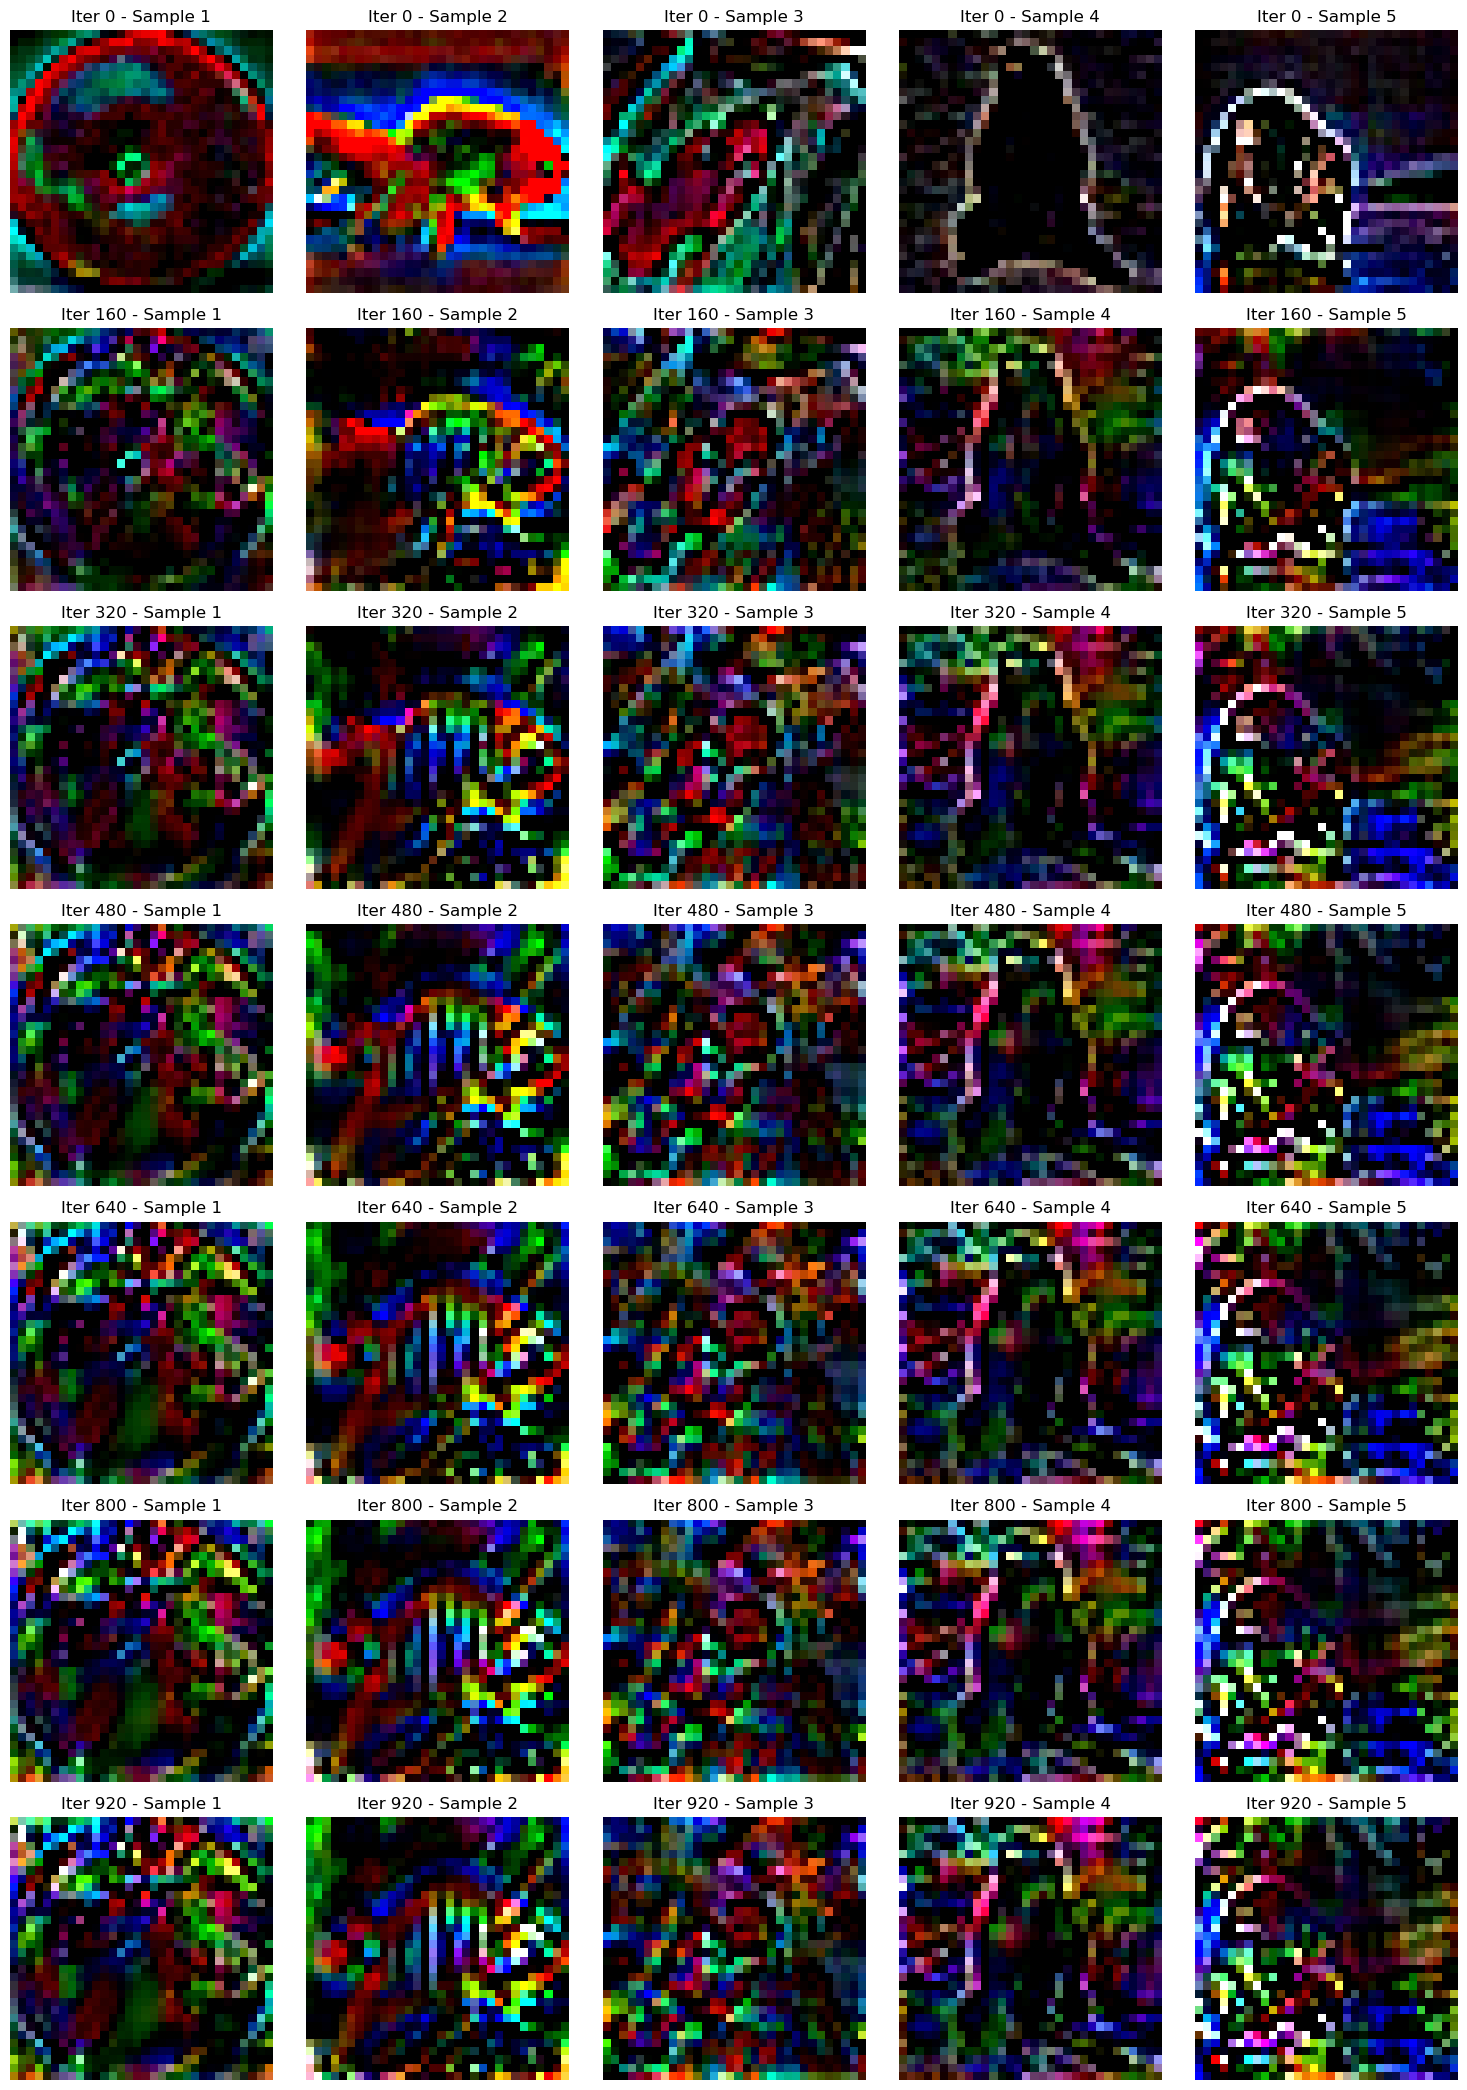

In [6]:
key_iterations = [0, 160, 320, 480, 640, 800, 920]
plot_evolution(distilled_data, key_iterations)

In [7]:
from sklearn.manifold import TSNE
import umap.umap_ as umap

def visualize_feature_space(distilled_data, iterations_to_show, method='tsne'):
    plt.figure(figsize=(15, 10))
    
    for i, iter_num in enumerate(iterations_to_show):
        # Assuming 'images' is the key for distilled images in your .npz files
        images = distilled_data[iter_num]['images']
        
        # Flatten images to feature vectors
        flat_images = images.reshape(images.shape[0], -1)
        
        # Dimensionality reduction
        if method == 'tsne':
            embedded = TSNE(n_components=2, random_state=42).fit_transform(flat_images)
        elif method == 'umap':  # umap
            reducer = umap.UMAP()
            embedded = reducer.fit_transform(flat_images)
        
        # Plot with different color for each iteration
        plt.scatter(embedded[:, 0], embedded[:, 1], label=f'Iter {iter_num}', alpha=0.7)
    
    plt.title(f'{method.upper()} Visualization of Distilled Images')
    plt.legend()
    plt.savefig(f'{method}_visualization.png', dpi=300)
    plt.show()

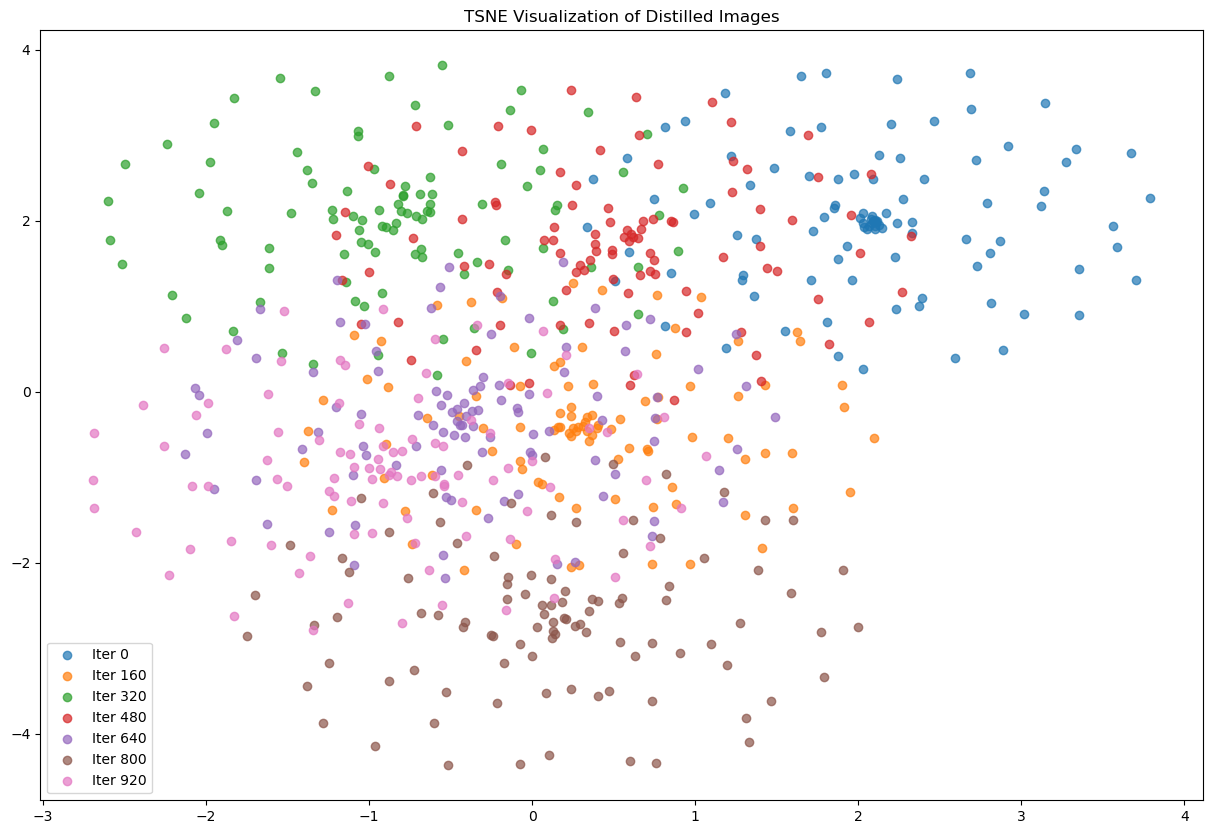

In [9]:
# Visualize using t-SNE
key_iterations = [0, 160, 320, 480, 640, 800, 920]
visualize_feature_space(distilled_data, key_iterations, method='tsne')

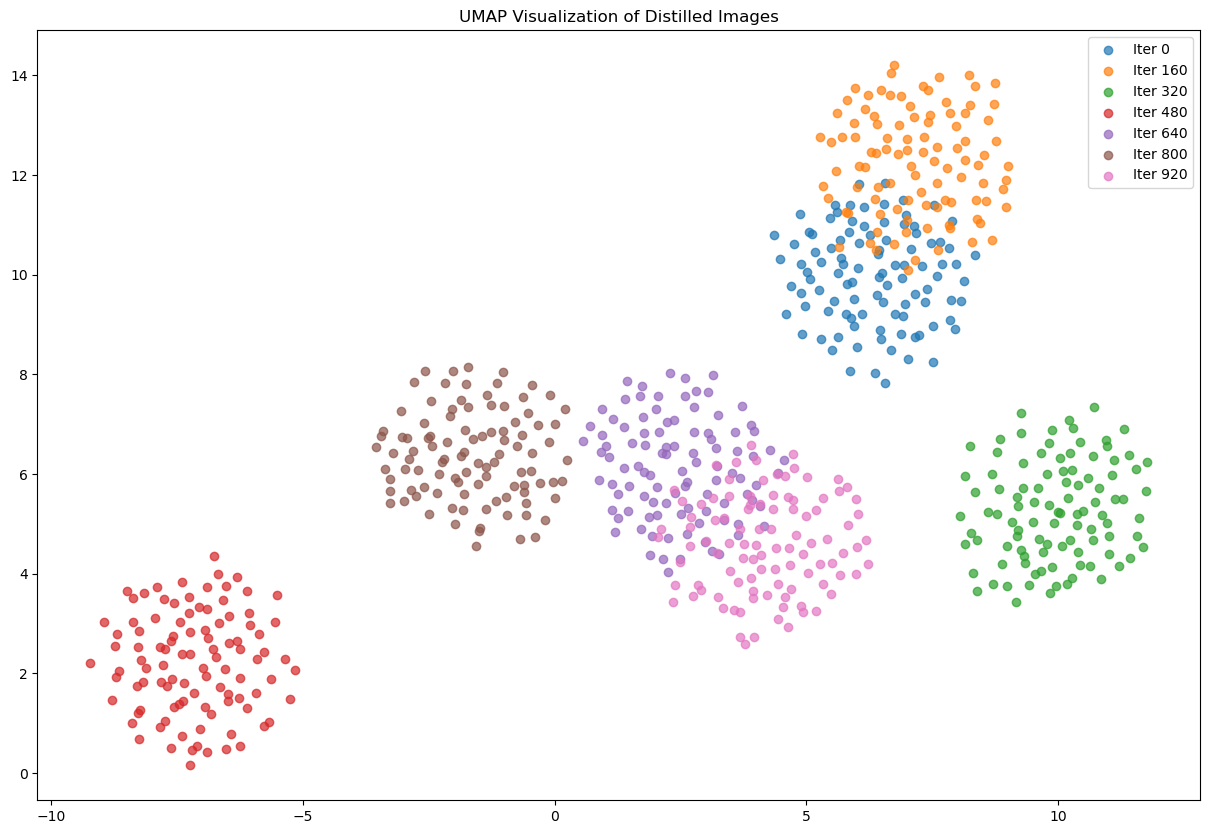

In [10]:
visualize_feature_space(distilled_data, key_iterations, method='umap')

In [11]:
import matplotlib.animation as animation

def create_distillation_animation(distilled_data, sample_idx=0):
    iterations = sorted(list(distilled_data.keys()))
    
    fig = plt.figure(figsize=(6, 6))
    
    images = []
    for iter_num in iterations:
        img = distilled_data[iter_num]['images'][sample_idx]
        if img.shape[0] == 1 or img.shape[0] == 3:  # Channel-first format
            img = np.transpose(img, (1, 2, 0))
        if img.shape[2] == 1:  # Grayscale
            im = plt.imshow(img.squeeze(), cmap='gray', animated=True)
        else:  # RGB
            im = plt.imshow(img, animated=True)
        plt.title(f'Iteration: {iter_num}')
        plt.axis('off')
        images.append([im])
    
    ani = animation.ArtistAnimation(fig, images, interval=200, blit=True)
    ani.save('distillation_progress.gif', writer='pillow', fps=5)
    plt.close()

# Create animation for the first sample
create_distillation_animation(distilled_data)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5844462..1.452686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.96575546..1.1284257].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9854477..1.089083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1171302..1.0944102].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0918267..1.1874924].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.102684..1.2493892].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0918357.

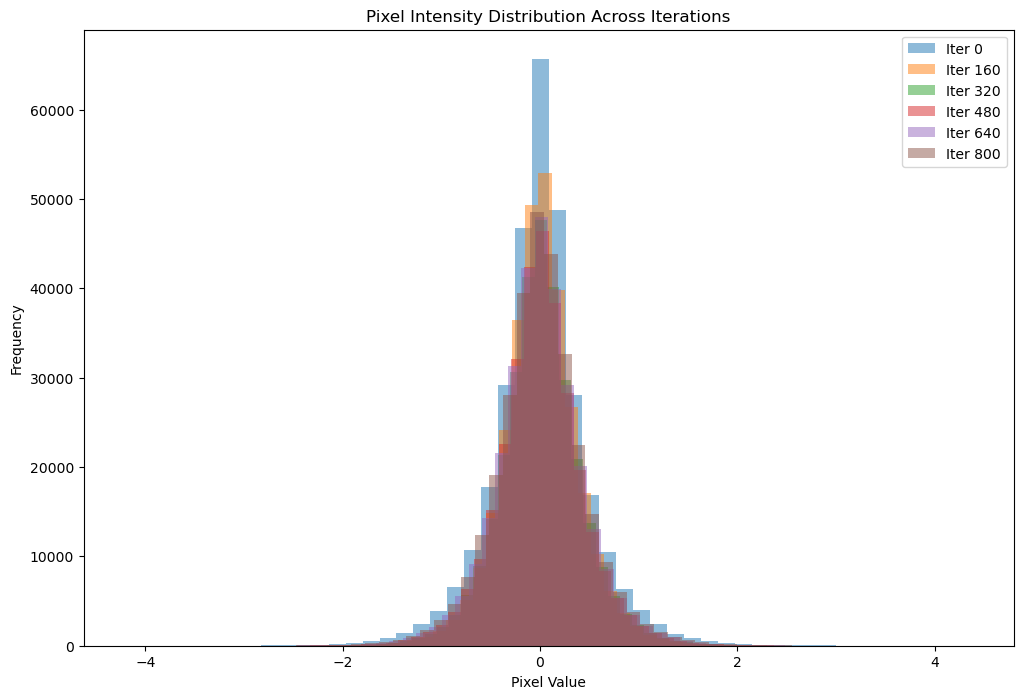

In [12]:
def track_pixel_distributions(distilled_data):
    iterations = sorted(list(distilled_data.keys()))
    sampled_iterations = iterations[::max(1, len(iterations)//5)]  # Sample ~5 iterations
    
    plt.figure(figsize=(12, 8))
    
    for iter_num in sampled_iterations:
        imgs = distilled_data[iter_num]['images']
        pixel_values = imgs.flatten()
        
        plt.hist(pixel_values, bins=50, alpha=0.5, label=f'Iter {iter_num}')
    
    plt.title('Pixel Intensity Distribution Across Iterations')
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    plt.legend()
    plt.savefig('pixel_distribution.png', dpi=300)
    plt.show()

track_pixel_distributions(distilled_data)